#### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.arima.model import ARIMA
import warnings
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
import numpy as np
from statsmodels.tsa.api import VAR
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller, kpss
import pandas as pd
import warnings


warnings.filterwarnings("ignore")

#### Read df

In [2]:
denmark = pd.read_csv("data/structured_data/denmark_data1.csv")
df = denmark
df.rename(columns={"Real GDP growth": "Real GDP"}, inplace=True)
df = df.dropna()
df = df.set_index("Date")
df.index = pd.DatetimeIndex(df.index, freq=pd.infer_freq(df.index))
df["GDP growth"] = 100 * np.log(df["Real GDP"]).diff()
df.drop(columns=["Real GDP"], inplace=True)
MAX_LAGS = 4
TARGET   = 'GDP growth'

#### Stationarity

In [3]:
# ─────────────────────────────────────────────
# 2. STATIONARITY CHECK & TRANSFORMATION
# ─────────────────────────────────────────────
def check_stationarity(df, significance=0.05):
    """
    ADF test on every column.
    Returns a dict: {col: True if stationary, False if not}
    """
    print("\n" + "="*65)
    print("  STATIONARITY CHECKS (ADF Test)")
    print("="*65)
    results = {}
    for col in df.columns:
        pval = adfuller(df[col].dropna(), autolag='AIC')[1]
        stat = pval < significance
        status = "✅ Stationary" if stat else "❌ Non-stationary → will difference"
        print(f"  {col:<50} p={pval:.4f}  {status}")
        results[col] = stat
    return results

In [4]:
def make_stationary(df, stationarity_map):
    """
    First-difference any column that failed the ADF test.
    Re-tests after differencing and warns if still non-stationary.
    """
    df_out = df.copy()
    differenced = []

    for col, is_stationary in stationarity_map.items():
        if not is_stationary:
            df_out[col] = df[col].diff()
            differenced.append(col)

    df_out.dropna(inplace=True)

    # Re-test differenced columns
    if differenced:
        print("\n--- Re-testing after first differencing ---")
        for col in differenced:
            pval = adfuller(df_out[col].dropna(), autolag='AIC')[1]
            status = "✅ Now stationary" if pval < 0.05 else "⚠️  Still non-stationary (consider 2nd difference)"
            print(f"  {col:<50} p={pval:.4f}  {status}")

    print(f"\n  Differenced columns : {differenced}")
    print(f"  Kept as-is          : {[c for c in df.columns if stationarity_map[c]]}")
    print(f"  Final shape         : {df_out.shape}")
    return df_out, differenced



In [5]:
stationarity_map  = check_stationarity(df)
df_transformed, differenced_cols = make_stationary(df, stationarity_map)
df_transformed, differenced_cols = make_stationary(df_transformed, stationarity_map)
check_stationarity(df_transformed)


  STATIONARITY CHECKS (ADF Test)
  Retail Sales                                       p=0.3597  ❌ Non-stationary → will difference
  NET TRADE                                          p=0.0000  ✅ Stationary
  Inflation (HICP/CPI)                               p=0.9950  ❌ Non-stationary → will difference
  Unemployment rate                                  p=0.2021  ❌ Non-stationary → will difference
  Interest rate 10 year government bond yield        p=0.3475  ❌ Non-stationary → will difference
  Business Confidence Index                          p=0.0752  ❌ Non-stationary → will difference
  Stock Market Index                                 p=0.9987  ❌ Non-stationary → will difference
  Consumer Confidence Index                          p=0.0387  ✅ Stationary
  Oil price                                          p=0.1204  ❌ Non-stationary → will difference
  GFC                                                p=0.9731  ❌ Non-stationary → will difference
  ip                          

{'Retail Sales': True,
 'NET TRADE': True,
 'Inflation (HICP/CPI)': True,
 'Unemployment rate': True,
 'Interest rate 10 year government bond yield': True,
 'Business Confidence Index': True,
 'Stock Market Index': True,
 'Consumer Confidence Index': True,
 'Oil price': True,
 'GFC': True,
 'ip': True,
 'GDP growth': True}

In [6]:
# ─────────────────────────────────────────────
# KPSS STATIONARITY CHECK (confirmatory test)
# ─────────────────────────────────────────────
print("\n" + "="*65)
print("  STATIONARITY CHECKS (KPSS Test)")
print("  H₀: Series is stationary  →  reject means non-stationary")
print("="*65)

for col in df_transformed.columns:
    stat, pval, _, crit = kpss(df_transformed[col].dropna(), regression='ct', nlags='auto')
    status = "✅ Stationary" if pval > 0.05 else "❌ Non-stationary (reject H₀)"
    print(f"  {col:<50} p={pval:.4f}  {status}")


  STATIONARITY CHECKS (KPSS Test)
  H₀: Series is stationary  →  reject means non-stationary
  Retail Sales                                       p=0.1000  ✅ Stationary
  NET TRADE                                          p=0.0923  ✅ Stationary
  Inflation (HICP/CPI)                               p=0.1000  ✅ Stationary
  Unemployment rate                                  p=0.1000  ✅ Stationary
  Interest rate 10 year government bond yield        p=0.0100  ❌ Non-stationary (reject H₀)
  Business Confidence Index                          p=0.0338  ❌ Non-stationary (reject H₀)
  Stock Market Index                                 p=0.0922  ✅ Stationary
  Consumer Confidence Index                          p=0.0678  ✅ Stationary
  Oil price                                          p=0.0100  ❌ Non-stationary (reject H₀)
  GFC                                                p=0.0849  ✅ Stationary
  ip                                                 p=0.0835  ✅ Stationary
  GDP growth          

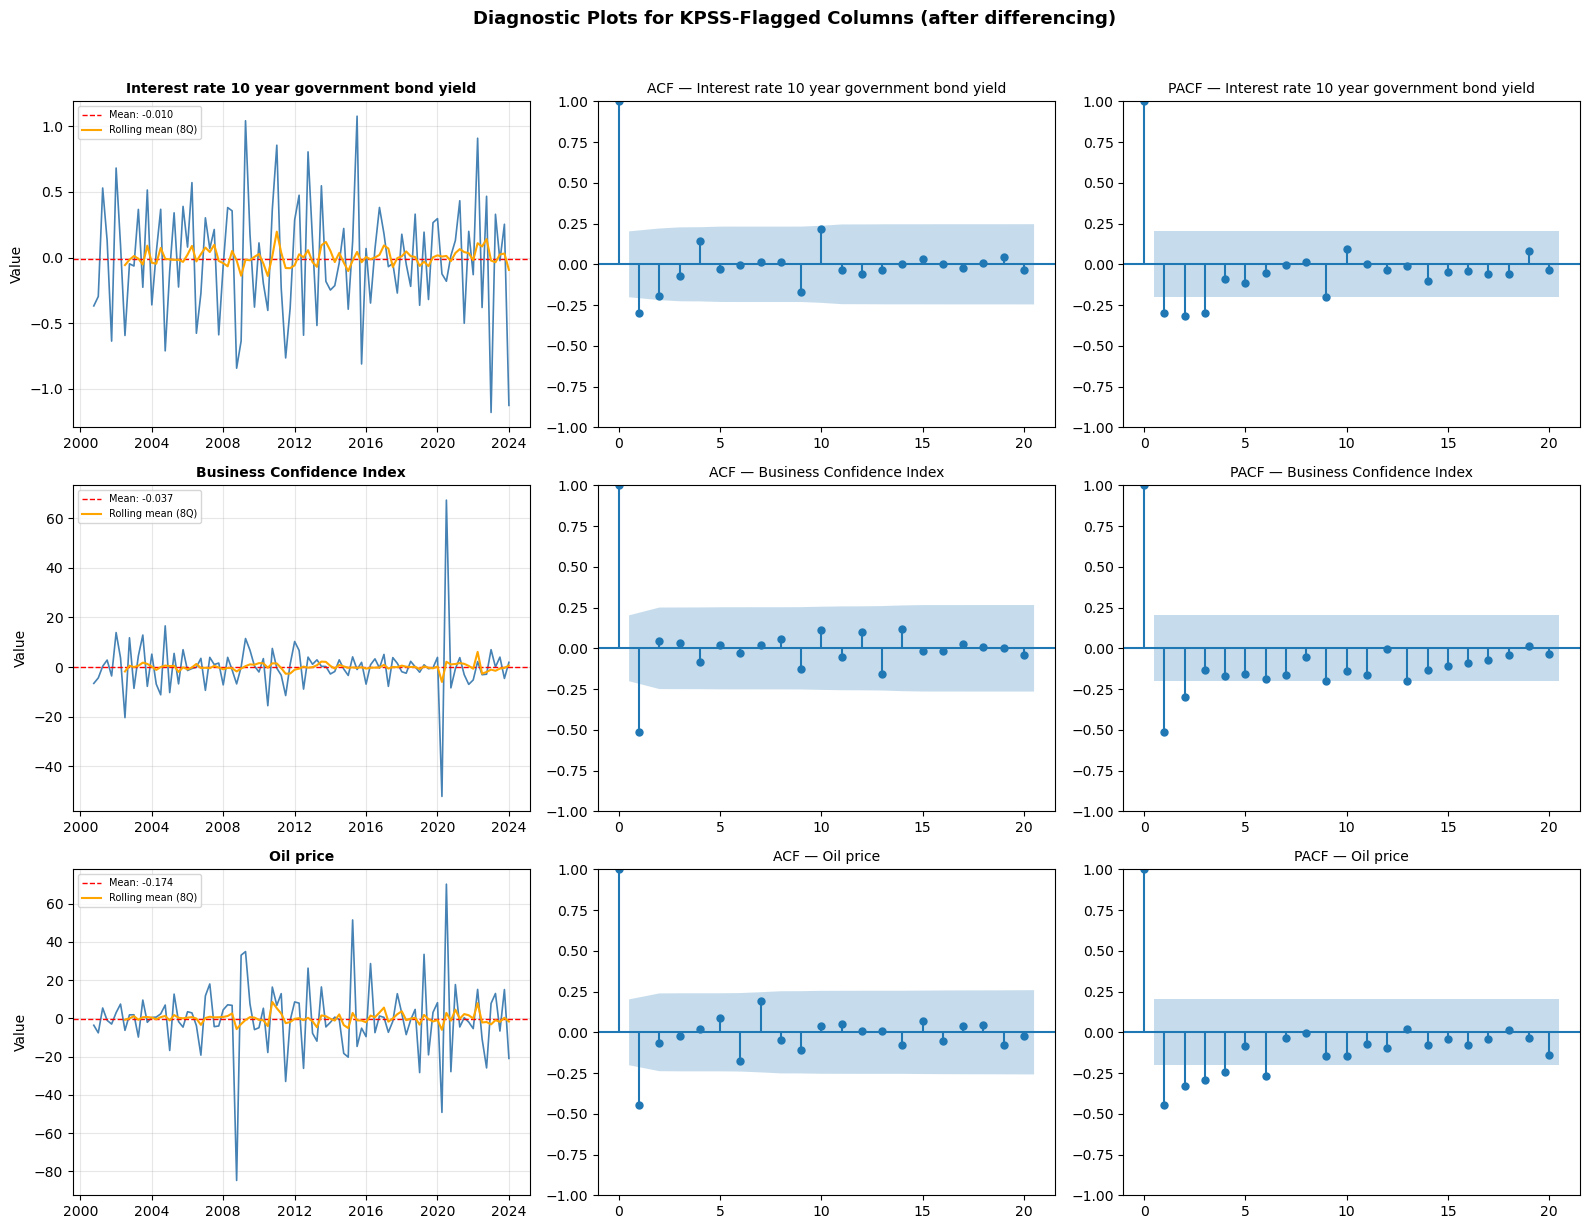

In [7]:
# ─────────────────────────────────────────────
# DIAGNOSTIC PLOTS: KPSS-flagged columns
# ─────────────────────────────────────────────
kpss_flagged = [
    'Interest rate 10 year government bond yield',
    'Business Confidence Index',
    'Oil price'
]

fig, axes = plt.subplots(len(kpss_flagged), 3, figsize=(16, 4 * len(kpss_flagged)))

for i, col in enumerate(kpss_flagged):
    series = df_transformed[col].dropna()

    # Time series plot
    axes[i, 0].plot(series.index, series.values, color='steelblue', linewidth=1.2)
    axes[i, 0].axhline(series.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {series.mean():.3f}')
    # Rolling mean to show if mean is drifting
    roll = series.rolling(window=8).mean()
    axes[i, 0].plot(roll.index, roll.values, color='orange', linewidth=1.5, label='Rolling mean (8Q)')
    axes[i, 0].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[i, 0].set_ylabel('Value')
    axes[i, 0].legend(fontsize=7)
    axes[i, 0].grid(True, alpha=0.3)

    # ACF
    plot_acf(series, ax=axes[i, 1], lags=20, alpha=0.05)
    axes[i, 1].set_title(f'ACF — {col}', fontsize=10)

    # PACF
    plot_pacf(series, ax=axes[i, 2], lags=20, alpha=0.05, method='ywm')
    axes[i, 2].set_title(f'PACF — {col}', fontsize=10)

plt.suptitle('Diagnostic Plots for KPSS-Flagged Columns (after differencing)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# ─────────────────────────────────────────────
# 3. HELPER: BUILD LAG MATRIX
# ─────────────────────────────────────────────
def build_lag_matrix(data, max_lags=4):
    lagged_frames = []
    for lag in range(1, max_lags + 1):
        shifted = data.shift(lag)
        shifted.columns = [f"{col}_L{lag}" for col in data.columns]
        lagged_frames.append(shifted)
    X = pd.concat(lagged_frames, axis=1).dropna()
    y = data.loc[X.index]
    return X, y


In [21]:

# ─────────────────────────────────────────────
# 4. WALK-FORWARD LASSO-VAR FORECAST
# ─────────────────────────────────────────────
n       = len(df_transformed)
n_test  = 19
n_train = n - n_test
h       = 1

actuals, predictions, forecast_dates = [], [], []
# Track which variables LASSO picks at each step
selection_log = []

tscv_inner = TimeSeriesSplit(n_splits=3)

for t in range(n_test):
    train = df_transformed.iloc[:n_train + t]

    # --- LASSO variable selection ---
    X_t, y_t = build_lag_matrix(train, max_lags=MAX_LAGS)
    if len(X_t) < 20:
        continue

    sc = StandardScaler()
    Xs = sc.fit_transform(X_t)

    lasso_t = LassoCV(cv=tscv_inner, max_iter=10000, random_state=42, n_alphas=100)
    lasso_t.fit(Xs, y_t[TARGET])

    sel_lags = X_t.columns[lasso_t.coef_ != 0].tolist()
    orig     = list(set([f.rsplit('_L', 1)[0] for f in sel_lags]))
    if TARGET not in orig:
        orig.append(TARGET)
    if len(orig) < 2:
        orig = [TARGET, df_transformed.columns[0]]

    # Log selection for this window
    quarter_label = df_transformed.index[n_train + t].strftime('%Y-Q%q') \
                    if hasattr(df_transformed.index[n_train + t], 'strftime') \
                    else str(df_transformed.index[n_train + t])[:7]
    selection_log.append({
        'step'      : t + 1,
        'date'      : df_transformed.index[n_train + t + h - 1],
        'lambda'    : round(lasso_t.alpha_, 5),
        'n_lags_sel': len(sel_lags),
        'variables' : sorted(orig)
    })

    # --- Fit reduced VAR ---
    try:
        sub   = train[orig]
        vm    = VAR(sub).fit(maxlags=MAX_LAGS, ic='aic')
        fi    = sub.values[-vm.k_ar:]
        fc    = vm.forecast(fi, steps=h)
        g_idx = list(sub.columns).index(TARGET)
        pred  = fc[-1, g_idx]
    except Exception:
        pred = train[TARGET].iloc[-1]

    actual = df_transformed[TARGET].iloc[n_train + t + h - 1]
    actuals.append(actual)
    predictions.append(pred)
    forecast_dates.append(df_transformed.index[n_train + t + h - 1])

actuals     = np.array(actuals)
predictions = np.array(predictions)


In [22]:
# ─────────────────────────────────────────────
# 5. PRINT VARIABLE SELECTION LOG
# ─────────────────────────────────────────────
print("\n" + "="*65)
print("  WALK-FORWARD LASSO-VAR")
print("="*65)
print("\n" + "="*65)
print("  LASSO VARIABLE SELECTION — PER ROLLING WINDOW")
print("="*65)
print(f"  {'Step':<6} {'Forecast Date':<14} {'λ':<10} {'#Lags':<7} Variables selected")
print("  " + "-"*60)
for entry in selection_log:
    vars_str = ", ".join(entry['variables'])
    print(f"  {entry['step']:<6} {str(entry['date'])[:10]:<14} "
          f"{entry['lambda']:<10} {entry['n_lags_sel']:<7} {vars_str}")

# Summary: how often was each variable selected?
print("\n" + "="*65)
print("  VARIABLE SELECTION FREQUENCY (across all rolling windows)")
print("="*65)
from collections import Counter
all_selected = [v for entry in selection_log for v in entry['variables']]
freq = Counter(all_selected)
total_steps = len(selection_log)
for var, count in sorted(freq.items(), key=lambda x: -x[1]):
    pct = count / total_steps * 100
    bar = "█" * int(pct / 5)
    print(f"  {var:<50} {count:>2}/{total_steps}  ({pct:5.1f}%)  {bar}")

# Clear summary of variables used to forecast GDP
print("\n" + "="*65)
print("  SUMMARY: VARIABLES USED TO FORECAST GDP GROWTH")
print("="*65)
unique_vars = sorted(set(v for entry in selection_log for v in entry['variables'] if v != TARGET))
print(f"\n  Target variable : {TARGET}")
print(f"  Predictor variables selected by LASSO (at least once):")
for var in unique_vars:
    count = freq[var]
    print(f"    • {var:<45} (used in {count}/{total_steps} windows)")
print(f"\n  Total unique predictors: {len(unique_vars)}")
print(f"  Variables never selected: {sorted(set(df_transformed.columns) - set(all_selected))}")


  WALK-FORWARD LASSO-VAR

  LASSO VARIABLE SELECTION — PER ROLLING WINDOW
  Step   Forecast Date  λ          #Lags   Variables selected
  ------------------------------------------------------------
  1      2019-07-01     0.33826    0       GDP growth, Retail Sales
  2      2019-10-01     0.3353     0       GDP growth, Retail Sales
  3      2020-01-01     0.33012    1       Consumer Confidence Index, GDP growth
  4      2020-04-01     0.33542    0       GDP growth, Retail Sales
  5      2020-07-01     0.36145    0       GDP growth, Retail Sales
  6      2020-10-01     0.37005    0       GDP growth, Retail Sales
  7      2021-01-01     0.3469     0       GDP growth, Retail Sales
  8      2021-04-01     0.3445     0       GDP growth, Retail Sales
  9      2021-07-01     0.38979    1       GDP growth, Unemployment rate
  10     2021-10-01     0.36049    0       GDP growth, Retail Sales
  11     2022-01-01     0.32724    0       GDP growth, Retail Sales
  12     2022-04-01     0.44133   

In [23]:
# ─────────────────────────────────────────────
# 6. NAIVE BENCHMARK
# ─────────────────────────────────────────────
naive_preds = df_transformed[TARGET].iloc[n_train - 1 : n_train + n_test - 1].values

# ─────────────────────────────────────────────
# 7. METRICS
# ─────────────────────────────────────────────
def compute_metrics(y_true, y_pred, label="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'─'*40}")
    print(f"  {label}")
    print(f"{'─'*40}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    return rmse, mae, r2

rmse_lasso, mae_lasso, r2_lasso = compute_metrics(actuals, predictions, "LASSO-VAR")
rmse_naive, mae_naive, r2_naive = compute_metrics(actuals, naive_preds, "Naïve (Random Walk)")

improvement = ((rmse_naive - rmse_lasso) / rmse_naive) * 100
print(f"\n  ✅ LASSO-VAR beats naïve by {improvement:.1f}% (RMSE)" if improvement > 0
      else f"\n  ❌ Naïve beats LASSO-VAR by {abs(improvement):.1f}% (RMSE)")



────────────────────────────────────────
  LASSO-VAR
────────────────────────────────────────
  RMSE : 3.0883
  MAE  : 2.1103
  R²   : -0.2942

────────────────────────────────────────
  Naïve (Random Walk)
────────────────────────────────────────
  RMSE : 4.4427
  MAE  : 3.1395
  R²   : -1.6784

  ✅ LASSO-VAR beats naïve by 30.5% (RMSE)


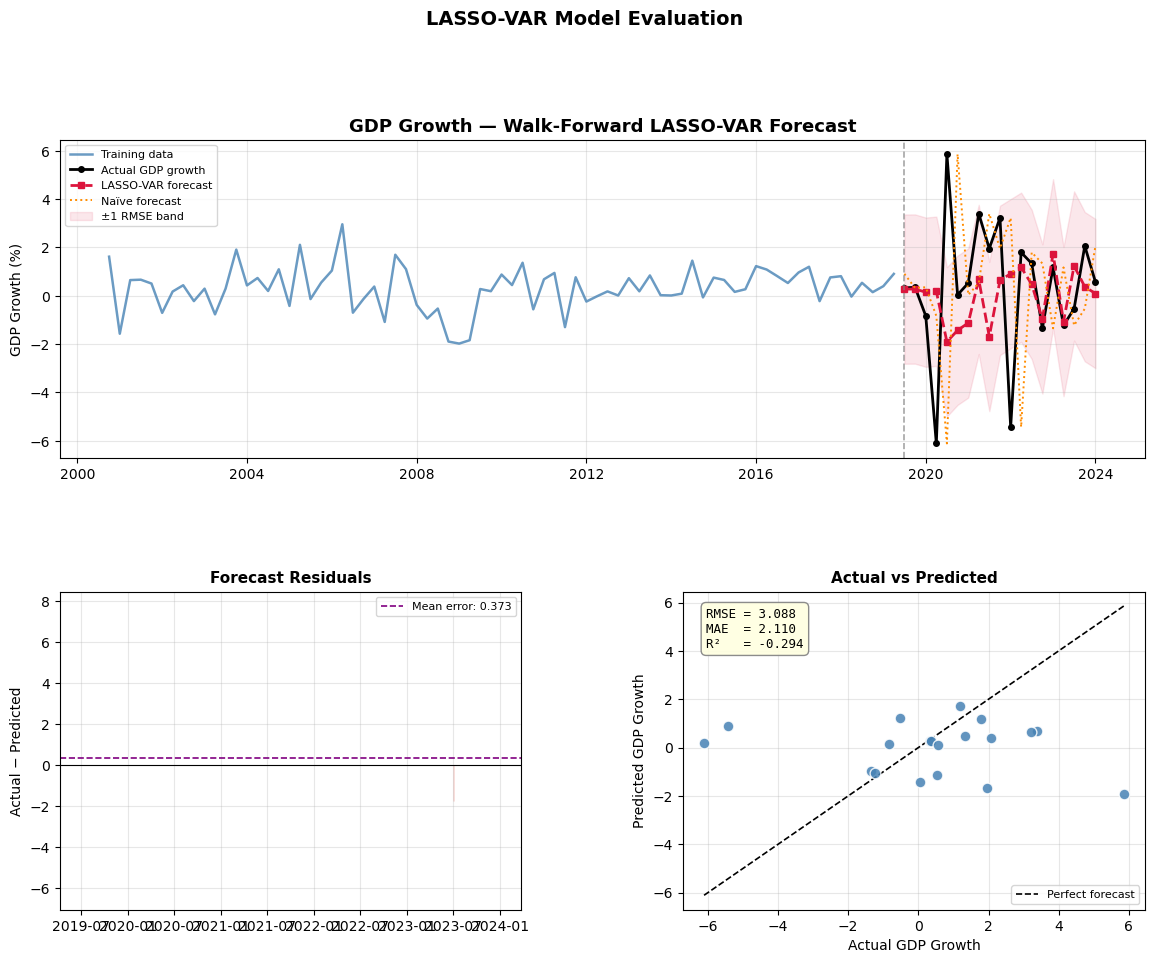

In [24]:
# ─────────────────────────────────────────────
# 8. PLOT
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

train_series = df_transformed[TARGET].iloc[:n_train]
ax1.plot(train_series.index, train_series.values,
         color='steelblue', linewidth=1.8, label='Training data', alpha=0.8)
ax1.plot(forecast_dates, actuals,
         color='black', linewidth=2.0, marker='o', markersize=4, label='Actual GDP growth')
ax1.plot(forecast_dates, predictions,
         color='crimson', linewidth=2.0, linestyle='--', marker='s', markersize=4,
         label='LASSO-VAR forecast')
ax1.plot(forecast_dates, naive_preds,
         color='darkorange', linewidth=1.4, linestyle=':', label='Naïve forecast')
ax1.axvline(x=df_transformed.index[n_train], color='gray',
            linestyle='--', linewidth=1.2, alpha=0.7)
ax1.fill_between(forecast_dates,
                 predictions - rmse_lasso,
                 predictions + rmse_lasso,
                 color='crimson', alpha=0.10, label='±1 RMSE band')
ax1.set_title('GDP Growth — Walk-Forward LASSO-VAR Forecast', fontsize=13, fontweight='bold')
ax1.set_ylabel('GDP Growth (%)')
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(True, alpha=0.3)

residuals = actuals - predictions
ax2.bar(forecast_dates, residuals,
        color=['#2ecc71' if r >= 0 else '#e74c3c' for r in residuals],
        alpha=0.8, edgecolor='white', linewidth=0.5)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axhline(residuals.mean(), color='purple', linestyle='--',
            linewidth=1.2, label=f'Mean error: {residuals.mean():.3f}')
ax2.set_title('Forecast Residuals', fontsize=11, fontweight='bold')
ax2.set_ylabel('Actual − Predicted')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

ax3.scatter(actuals, predictions, color='steelblue', edgecolors='white',
            s=60, alpha=0.85, zorder=3)
mn, mx = min(actuals.min(), predictions.min()), max(actuals.max(), predictions.max())
ax3.plot([mn, mx], [mn, mx], 'k--', linewidth=1.2, label='Perfect forecast')
ax3.set_xlabel('Actual GDP Growth')
ax3.set_ylabel('Predicted GDP Growth')
ax3.set_title('Actual vs Predicted', fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3)
metrics_text = (f"RMSE = {rmse_lasso:.3f}\n"
                f"MAE  = {mae_lasso:.3f}\n"
                f"R²   = {r2_lasso:.3f}")
ax3.text(0.05, 0.95, metrics_text, transform=ax3.transAxes,
         fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                   edgecolor='gray', alpha=0.9),
         fontfamily='monospace')
ax3.legend(fontsize=8)

plt.suptitle('LASSO-VAR Model Evaluation', fontsize=14, fontweight='bold', y=1.01)
plt.savefig("lasso_var_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()